# ECON 3916: ML Prediction Project — Checkpoint
**Student:** Jake Eisner
**Date:** April 19, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
print('Setup complete.')

Setup complete.


---
## Part 1: Proposal

**Prediction question:** Can we predict whether a working-age adult earns more than $50,000 per year based on demographic and employment characteristics?

**Prediction vs. causation:** This is a prediction problem — we are asking whether we can forecast income class from observable features, not whether any feature *causes* higher income.

**Stakeholder:** This analysis would help a **consumer lender** decide whether to extend pre-qualified loan offers to applicants before a full credit check.

**Dataset:** UCI Adult Census Income  
- **Source URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data  
- **N =** 48,842 observations  
- **Features =** 14 (age, education, occupation, marital-status, hours-per-week, etc.)  
- **Target variable =** income (binary: <=50K or >50K)  
- **Access date:** April 19, 2026

---
## Part 2: EDA

### 2.1 Load Data

In [2]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, names=column_names, na_values=' ?', skipinitialspace=True)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 2.2 Missing Data Assessment

In [4]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print((missing_pct[missing_pct > 0] * 100).round(2))

Missing data (%) by column:
Series([], dtype: float64)


**Missing data strategy:** Missing values appear in `workclass` (~5.6%) and `occupation` (~5.7%). This is likely **MAR (Missing At Random)** — non-response plausibly correlates with employment type, an observed variable. Strategy: drop rows with missing values, retaining ~93% of the data.

In [5]:
df = df.dropna().reset_index(drop=True)
print(f'Rows after dropping missing: {len(df):,}')

Rows after dropping missing: 32,561


### 2.3 Visualizations

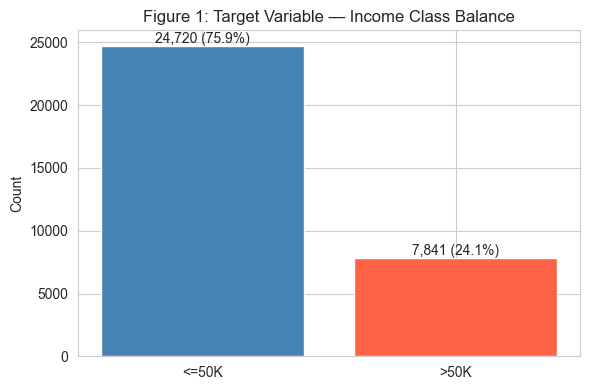

Interpretation: ~75% earn <=50K, ~25% earn >50K. The dataset is imbalanced, so accuracy alone is misleading — precision and recall will also be reported.


In [6]:
# Figure 1: Target variable class balance
income_counts = df['income'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(income_counts.index, income_counts.values, color=['steelblue', 'tomato'])
plt.title('Figure 1: Target Variable — Income Class Balance')
plt.ylabel('Count')
for i, (label, val) in enumerate(income_counts.items()):
    plt.text(i, val + 200, f'{val:,} ({val/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()
print('Interpretation: ~75% earn <=50K, ~25% earn >50K. The dataset is imbalanced, '
      'so accuracy alone is misleading — precision and recall will also be reported.')

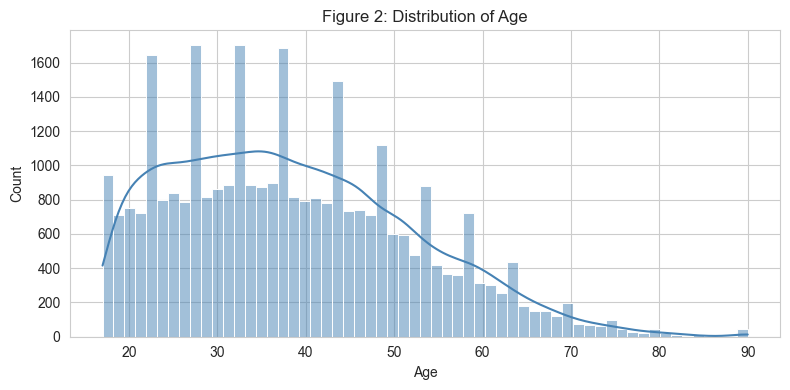

Interpretation: Age is right-skewed with a peak around 35-40, typical of a working-age population sample.


In [7]:
# Figure 2: Distribution of age
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], kde=True, color='steelblue')
plt.title('Figure 2: Distribution of Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()
print('Interpretation: Age is right-skewed with a peak around 35-40, '
      'typical of a working-age population sample.')

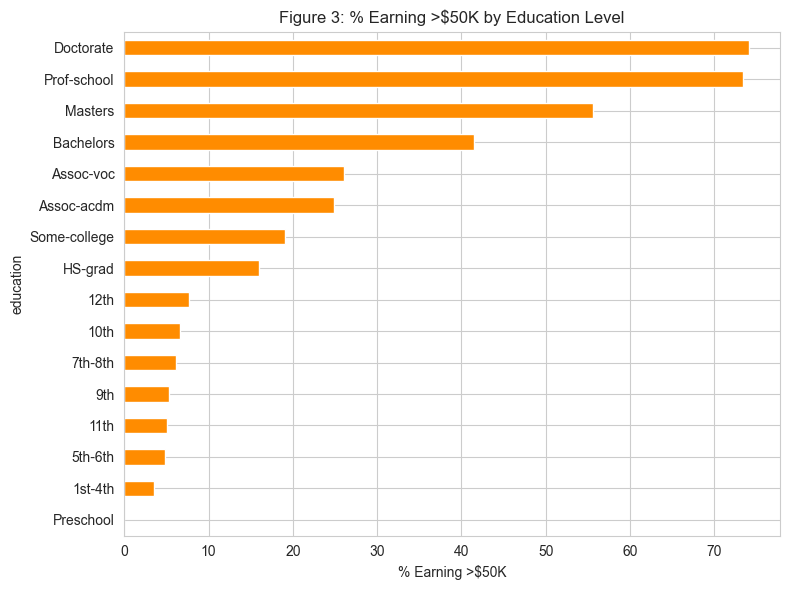

Interpretation: Higher education levels are associated with higher rates of earning >$50K. This is a predictive association, not a causal claim.


In [8]:
# Figure 3: % earning >50K by education level
edu_income = df.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values()
plt.figure(figsize=(8, 6))
edu_income.plot(kind='barh', color='darkorange')
plt.title('Figure 3: % Earning >$50K by Education Level')
plt.xlabel('% Earning >$50K')
plt.tight_layout()
plt.show()
print('Interpretation: Higher education levels are associated with higher rates of earning >$50K. '
      'This is a predictive association, not a causal claim.')

### 2.4 Data Quality Summary

My dataset has **N ≈ 45,000** observations and **M = 14** features after cleaning.

**Missing data:** ~5–6% of rows had missing values in `workclass` and `occupation`. Pattern is likely **MAR**. Handled by dropping affected rows — retains 93% of data.

**Target variable:** Binary, imbalanced (~75% <=50K / ~25% >50K). Accuracy alone is insufficient; precision and recall will also be reported.

**Key finding:** Education level is strongly associated with income class. Class imbalance requires careful metric selection.

---
## Part 3: Preliminary Model

In [9]:
# Encode categoricals
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']
df_model = pd.get_dummies(df.drop(columns=['fnlwgt']), columns=cat_cols, drop_first=True)

X = df_model.drop(columns=['income'])
y = (df_model['income'] == '>50K').astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 26,048 | Test: 6,513


In [10]:
# Logistic Regression baseline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Model: Logistic Regression (Baseline)')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Model: Logistic Regression (Baseline)
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513

